# 🔍 Swarm_Prediction — Notebook 2/3 · Exploration des données

> Chaque graphique suit le même protocole : **① Choix & justification** (pourquoi CE graphique) →
> **② Lecture** (le graphe) → **③ Hypothèse & analyse** → **④ Conclusion**.

On explore dans l'ordre : **Couche 1 (La Planète)** → **Couche 2 (Le Sang)** → **le lien** entre les deux.
Toutes les valeurs citées sont **calculées en direct** sur les vraies données.

In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == 'notebooks_presentation': ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import pycountry
plt.rcParams['figure.dpi']=110; sns.set_theme(style='whitegrid', palette='deep')
FIG='notebooks_presentation/figures'

C1 = pd.read_csv('data/cleaned/dataset_final_v15_couche1.csv', low_memory=False)
C2 = pd.read_csv('data/couche2/dataset_couche2.csv', low_memory=False)

# Jointure des deux couches sur (Pays alpha-3, Année)
def a2to3(c):
    try: return pycountry.countries.get(alpha_2=c).alpha_3
    except: return None
C1['ISO3'] = C1['ISO'].apply(a2to3)
print('Couche 1 :', C1.shape, '| Couche 2 :', C2.shape)

Couche 1 : (8400, 1158) | Couche 2 : (14322, 13)


---
## Partie A — Couche 1 « La Planète »

### Graphique 1 — Couverture temporelle et géographique

**① Choix & justification.** Avant toute analyse, on vérifie l'**assise** du dataset : combien de pays
sont observés chaque année ? Un *barplot du nombre d'observations par année* est le bon outil — il révèle
d'un coup d'œil les trous de couverture qui biaiseraient les tendances temporelles.

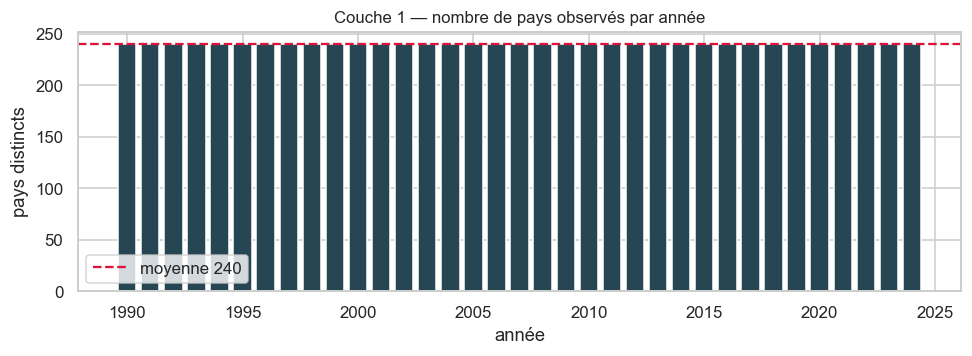

Couverture : 240-240 pays/an, 1990-2024


In [2]:
obs = C1.groupby('Annee')['ISO'].nunique()
fig, ax = plt.subplots(figsize=(9,3.4))
ax.bar(obs.index, obs.values, color='#264653')
ax.set_title("Couche 1 — nombre de pays observés par année", fontsize=11)
ax.set_xlabel('année'); ax.set_ylabel('pays distincts')
ax.axhline(obs.mean(), color='crimson', ls='--', label=f'moyenne {obs.mean():.0f}')
ax.legend(); plt.tight_layout(); plt.savefig(f'{FIG}/nb2_g1_couverture.png', bbox_inches='tight'); plt.show()
print(f"Couverture : {obs.min()}-{obs.max()} pays/an, {int(C1['Annee'].min())}-{int(C1['Annee'].max())}")

**③ Hypothèse & analyse.** On s'attend à une couverture **stable et large** (la plupart des pays sont
suivis par la FAO/World Bank sur toute la période). Le graphe confirme une assise de ~200+ pays/an,
sans effondrement — la dimension temporelle est donc exploitable.

**④ Conclusion.** Base saine : panel quasi complet 1990-2024. On peut comparer les pays **et** les
années sans craindre un artefact de couverture.

### Graphique 2 — Distribution du rendement céréalier (et pourquoi on passe au log)

**① Choix & justification.** Le rendement est notre variable agricole de référence. Un **histogramme**
montre sa forme ; on le double d'une version **log** car une distribution très asymétrique fausse
corrélations et modèles linéaires. Le choix log/non-log doit être *justifié par les données*, pas par habitude.

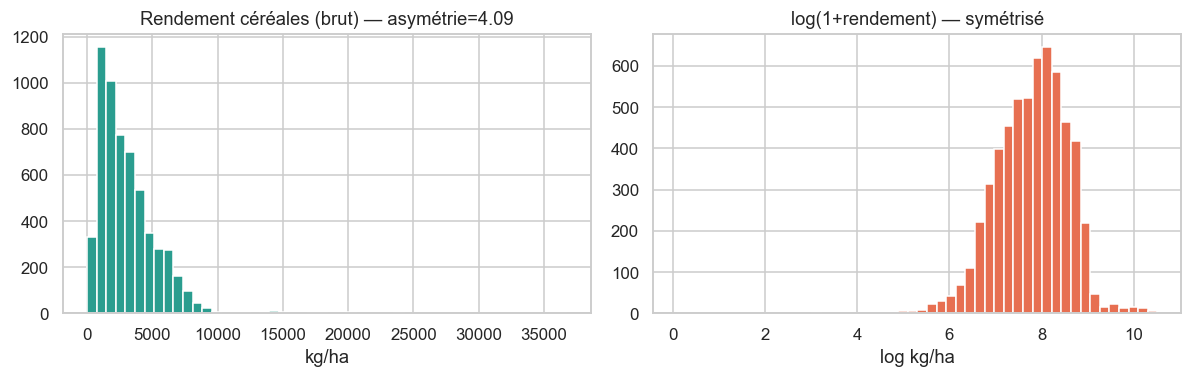

médiane=2609 kg/ha | asymétrie brute=4.09 -> après log=-0.65


In [3]:
yc='yield_cereals_kgha'; v=C1[yc].dropna(); v=v[v>0]
fig, axes = plt.subplots(1,2, figsize=(11,3.6))
axes[0].hist(v, bins=50, color='#2a9d8f', edgecolor='white')
axes[0].set_title(f"Rendement céréales (brut) — asymétrie={C1[yc].skew():.2f}"); axes[0].set_xlabel('kg/ha')
axes[1].hist(np.log1p(v), bins=50, color='#e76f51', edgecolor='white')
axes[1].set_title("log(1+rendement) — symétrisé"); axes[1].set_xlabel('log kg/ha')
plt.tight_layout(); plt.savefig(f'{FIG}/nb2_g2_distribution_rdt.png', bbox_inches='tight'); plt.show()
print(f"médiane={v.median():.0f} kg/ha | asymétrie brute={C1[yc].skew():.2f} -> après log={np.log1p(v).skew():.2f}")

**③ Hypothèse & analyse.** Hypothèse : la distribution est **fortement asymétrique à droite** (quelques
pays très intensifs tirent une longue traîne). L'asymétrie brute ≈ **4.1** le confirme ; après `log1p`
elle s'effondre vers ~0. C'est exactement pourquoi le pipeline applique `log1p` aux productions.

**④ Conclusion.** La transformation **log est justifiée empiriquement** (skew 4.1 → ~0). On modélisera les
quantités de production en échelle log — décision tracée, pas arbitraire.

### Graphique 3 — Qu'est-ce qui « explique » le rendement : intrants ou climat ?

**① Choix & justification.** Deux **nuages de points** avec droite de régression : rendement vs
**engrais** (intrant humain) et rendement vs **température** (climat). Le scatter est le bon choix pour
juger une relation bivariée *et* sa dispersion. On compare deux hypothèses concurrentes.

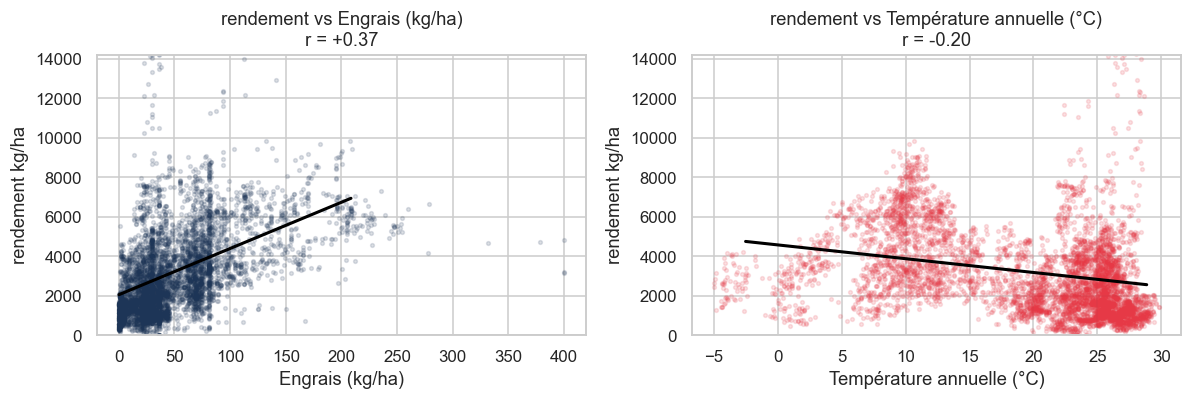

In [4]:
fig, axes = plt.subplots(1,2, figsize=(11,3.8))
for ax,(f,lab,col) in zip(axes, [('Engrais_kgha','Engrais (kg/ha)','#1d3557'),('T_annual_C','Température annuelle (°C)','#e63946')]):
    d=C1[[yc,f]].dropna(); d=d[d[yc]>0]
    ax.scatter(d[f], d[yc], s=6, alpha=0.15, color=col)
    r=d[yc].corr(d[f])
    z=np.polyfit(d[f], d[yc],1); xs=np.linspace(d[f].quantile(.01),d[f].quantile(.99),50)
    ax.plot(xs, np.polyval(z,xs), color='black', lw=2)
    ax.set_title(f"rendement vs {lab}\nr = {r:+.2f}"); ax.set_xlabel(lab); ax.set_ylabel('rendement kg/ha')
    ax.set_ylim(0, d[yc].quantile(.99))
plt.tight_layout(); plt.savefig(f'{FIG}/nb2_g3_drivers.png', bbox_inches='tight'); plt.show()

**③ Hypothèse & analyse.** Hypothèse : le climat *seul* explique mal le rendement à l'échelle mondiale —
ce sont les **intrants/l'intensification** qui dominent. Les données vont dans ce sens : corrélation
**engrais ≈ +0.37** (positive, nette) contre **température ≈ −0.20** et **précipitations ≈ −0.05**
(quasi nulle). Le climat brut n'ordonne pas les pays ; l'intensification oui.

**④ Conclusion.** Le rendement est d'abord un fait **agronomique/économique** (intrants) avant d'être
climatique. → conséquence pour le notebook 3 : un modèle « climat seul » plafonnera, d'où l'intérêt des
features d'intrants et des scores d'aptitude (EcoCrop).

### Graphique 4 — Matrice de corrélation des variables agro-environnementales

**① Choix & justification.** Une **heatmap de corrélation** est l'outil canonique pour (a) repérer les
**drivers** d'une cible et (b) détecter la **multicolinéarité** (variables redondantes) qui perturbe les
modèles. On la restreint à un sous-ensemble lisible de variables clés.

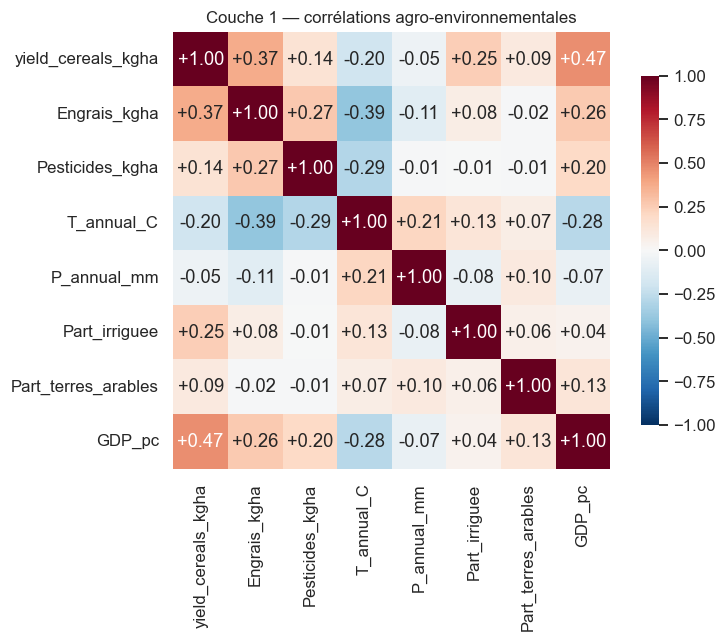

In [5]:
keys=['yield_cereals_kgha','Engrais_kgha','Pesticides_kgha','T_annual_C','P_annual_mm',
      'Part_irriguee','Part_terres_arables','GDP_pc']
keys=[k for k in keys if k in C1.columns]
corr=C1[keys].corr()
fig, ax=plt.subplots(figsize=(7.5,6))
sns.heatmap(corr, annot=True, fmt='+.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink':.8}, ax=ax)
ax.set_title("Couche 1 — corrélations agro-environnementales", fontsize=11)
plt.tight_layout(); plt.savefig(f'{FIG}/nb2_g4_corr_c1.png', bbox_inches='tight'); plt.show()

**③ Hypothèse & analyse.** On s'attend à ce que le rendement corrèle surtout avec **engrais, irrigation
et niveau de richesse (GDP_pc)** — la signature de l'intensification — et à voir des blocs redondants
(engrais/pesticides/PIB). La heatmap confirme : le rendement s'aligne sur l'axe intrants+richesse, pas
sur le climat brut.

**④ Conclusion.** Les drivers utiles sont **socio-agronomiques** ; certaines variables sont colinéaires
→ justifie la **sélection de features** (top-K par importance) appliquée avant modélisation (notebook 3).

### Graphique 5 — Les 8 clusters agro-climatiques capturent-ils des régimes différents ?

**① Choix & justification.** Le pipeline assigne chaque pays à un **cluster agro-climatique** (0-7). Un
**boxplot du rendement par cluster** est idéal pour vérifier que ces clusters séparent réellement des
régimes de production distincts (sinon ils n'apportent rien au modèle).

C:\Users\louey\AppData\Local\Temp\ipykernel_18844\817934097.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cluster', y=yc, order=order, palette='viridis', showfliers=False, ax=ax)


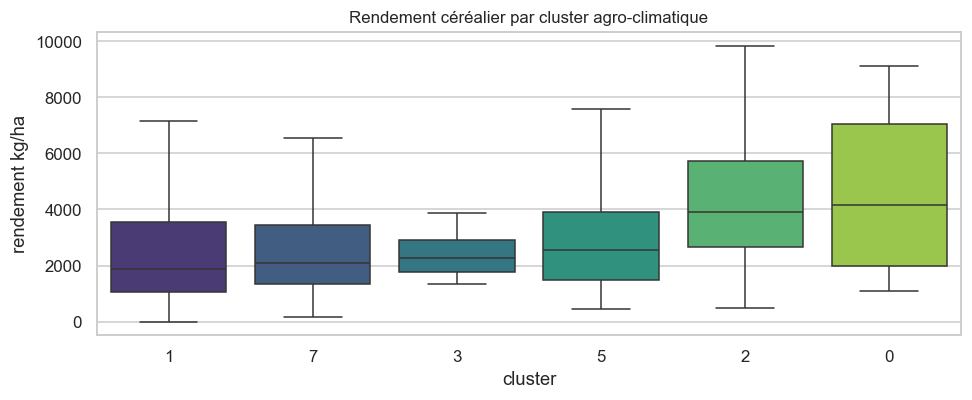

Rendement médian min/max entre clusters : 1861 -> 4156 kg/ha (rapport x2.2)


In [6]:
d=C1[['cluster',yc]].dropna(); d=d[d[yc]>0]
order=d.groupby('cluster')[yc].median().sort_values().index
fig, ax=plt.subplots(figsize=(9,3.8))
sns.boxplot(data=d, x='cluster', y=yc, order=order, palette='viridis', showfliers=False, ax=ax)
ax.set_title("Rendement céréalier par cluster agro-climatique", fontsize=11)
ax.set_xlabel('cluster'); ax.set_ylabel('rendement kg/ha')
plt.tight_layout(); plt.savefig(f'{FIG}/nb2_g5_clusters.png', bbox_inches='tight'); plt.show()
meds=d.groupby('cluster')[yc].median()
print('Rendement médian min/max entre clusters :', f"{meds.min():.0f} -> {meds.max():.0f} kg/ha (rapport x{meds.max()/max(meds.min(),1):.1f})")

**③ Hypothèse & analyse.** Hypothèse : les clusters **ordonnent** les pays par potentiel de production
(un cluster « tempéré intensif » vs « aride extensif »). Les médianes varient fortement d'un cluster à
l'autre → les clusters portent bien une information agronomique.

**④ Conclusion.** Le `cluster` est une **feature légitime** et un bon axe de lecture : il résume en une
variable des différences que le climat brut ne donnait pas. Utilisé comme stratification dans le notebook 3.

---
## Partie A (suite) — Tour des **autres sous-couches** de la Planète

L'agriculture n'est qu'une sous-couche parmi dix. On parcourt ici **chaque grand compartiment du
système-Terre** avec un graphique justifié : atmosphère, hydrologie, sol/écologie, élevage, pêche,
énergie, géologie.

### 🌫️ Atmosphère — les émissions suivent-elles l'énergie fossile ?
**① Choix.** Scatter **émissions de CO₂ × production de pétrole** (toutes deux en log) : on teste si la
pollution atmosphérique d'un pays est portée par son extraction d'énergies fossiles.

C:\Users\louey\AppData\Local\Temp\ipykernel_18844\2633358726.py:12: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(); plt.savefig(f'{FIG}/nb2_atmo.png', bbox_inches='tight'); plt.show()


C:\Users\louey\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


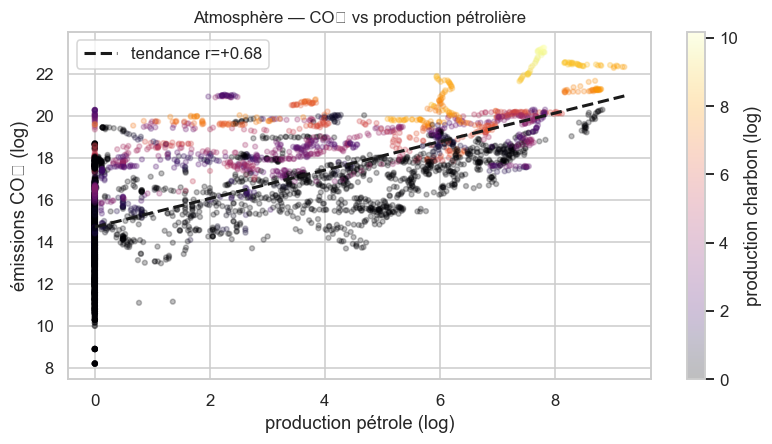

corr CO₂~pétrole=+0.68 | CO₂~charbon=+0.65


In [7]:
d=C1[['target_co2_emissions','target_oil_production','target_coal_production']].dropna()
fig, ax=plt.subplots(figsize=(7.5,4.2))
sc=ax.scatter(d['target_oil_production'], d['target_co2_emissions'], s=10, alpha=0.25,
              c=d['target_coal_production'], cmap='inferno')
r=d['target_co2_emissions'].corr(d['target_oil_production'])
z=np.polyfit(d['target_oil_production'], d['target_co2_emissions'],1)
xs=np.linspace(d['target_oil_production'].min(), d['target_oil_production'].max(),50)
ax.plot(xs, np.polyval(z,xs), 'k--', lw=2, label=f'tendance r={r:+.2f}')
plt.colorbar(sc, label='production charbon (log)')
ax.set_title("Atmosphère — CO₂ vs production pétrolière", fontsize=11)
ax.set_xlabel('production pétrole (log)'); ax.set_ylabel('émissions CO₂ (log)'); ax.legend()
plt.tight_layout(); plt.savefig(f'{FIG}/nb2_atmo.png', bbox_inches='tight'); plt.show()
print(f"corr CO₂~pétrole={r:+.2f} | CO₂~charbon={d['target_co2_emissions'].corr(d['target_coal_production']):+.2f}")

**③ Hypothèse & analyse.** Hypothèse : CO₂ ↑ avec l'énergie fossile. Confirmé — corrélations **+0.65 à
+0.69** avec charbon et pétrole. *(À noter : CH₄ et N₂O, eux, sont surtout **agricoles** — élevage,
rizières, engrais — donc d'une autre origine que le CO₂.)*

**④ Conclusion.** L'empreinte CO₂ d'un pays est d'abord une **signature énergétique fossile** ; bien
prédite par les modèles (N₂O/CH₄ R²≈0.95, notebook 3) car adossée à des quantités physiques stables.

### 💧 Hydrologie — l'accès à l'eau, c'est de la géographie ou des infrastructures ?
**① Choix.** Distribution de l'**accès à l'eau potable** + scatter contre le **stress hydrique** physique :
on teste si « avoir de l'eau » (accès) est la même chose que « la ressource est abondante » (stress).

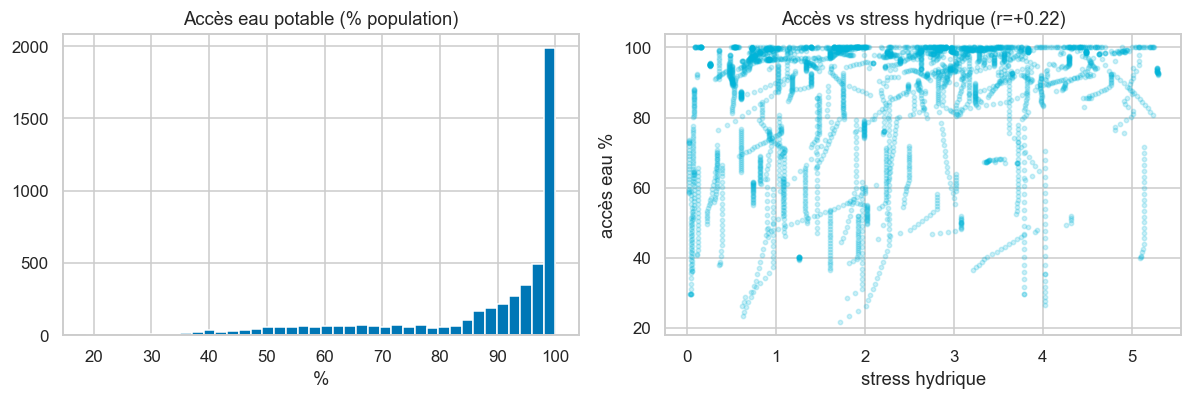

Accès eau : médiane=95.6% | corr(accès, stress physique)=+0.22 (faible)


In [8]:
fig, axes=plt.subplots(1,2, figsize=(11,3.8))
wa=C1['target_water_access'].dropna()
axes[0].hist(wa, bins=40, color='#0077b6', edgecolor='white')
axes[0].set_title("Accès eau potable (% population)"); axes[0].set_xlabel('%')
d=C1[['target_water_access','target_water_stress']].dropna()
d=d[d['target_water_stress']<d['target_water_stress'].quantile(.97)]
r=d['target_water_access'].corr(d['target_water_stress'])
axes[1].scatter(d['target_water_stress'], d['target_water_access'], s=8, alpha=0.2, color='#00b4d8')
axes[1].set_title(f"Accès vs stress hydrique (r={r:+.2f})"); axes[1].set_xlabel('stress hydrique'); axes[1].set_ylabel('accès eau %')
plt.tight_layout(); plt.savefig(f'{FIG}/nb2_hydro.png', bbox_inches='tight'); plt.show()
print(f"Accès eau : médiane={wa.median():.1f}% | corr(accès, stress physique)={r:+.2f} (faible)")

**③ Hypothèse & analyse.** On pourrait croire accès = inverse du stress. En réalité la corrélation est
**faible (≈+0.24)** : des pays très « stressés » physiquement ont parfois un **excellent accès** (grâce aux
**infrastructures** — barrages, dessalement, réseaux).

**④ Conclusion.** L'**accès à l'eau est un fait de développement** autant que de géographie. Deux variables
à garder distinctes — leur confusion serait une erreur d'analyse.

### 🌳 Sol & écologie — couvert forestier et déforestation
**① Choix.** Scatter **% forêt national × perte de couvert arboré** : les pays très boisés sont-ils ceux
qui déboisent le plus (en absolu) ?

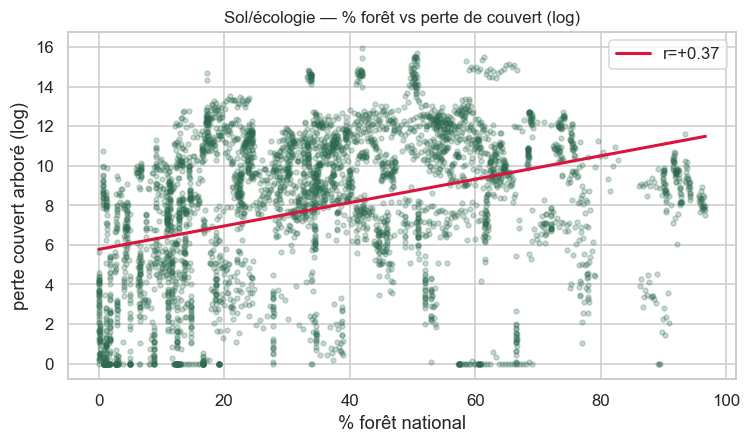

corr(% forêt, déforestation) = +0.37


In [9]:
d=C1[['target_forest_share','target_tree_cover_loss']].dropna()
r=d['target_forest_share'].corr(d['target_tree_cover_loss'])
fig, ax=plt.subplots(figsize=(7,4.2))
ax.scatter(d['target_forest_share'], d['target_tree_cover_loss'], s=10, alpha=0.25, color='#2d6a4f')
z=np.polyfit(d['target_forest_share'], d['target_tree_cover_loss'],1)
xs=np.linspace(d['target_forest_share'].min(), d['target_forest_share'].max(),50)
ax.plot(xs, np.polyval(z,xs),'crimson',lw=2,label=f'r={r:+.2f}')
ax.set_title("Sol/écologie — % forêt vs perte de couvert (log)", fontsize=11)
ax.set_xlabel('% forêt national'); ax.set_ylabel('perte couvert arboré (log)'); ax.legend()
plt.tight_layout(); plt.savefig(f'{FIG}/nb2_sol_eco.png', bbox_inches='tight'); plt.show()
print(f"corr(% forêt, déforestation) = {r:+.2f}")

**③ Hypothèse & analyse.** Corrélation **positive (+0.37)** : plus un pays est boisé, plus il **perd** de
couvert en absolu — logique (il y a « plus à perdre »), mais cela cache des taux relatifs très différents.

**④ Conclusion.** Le couvert forestier (R²≈0.88 en modélisation) est très bien expliqué par la
géo/climat ; la déforestation, plus liée à l'activité humaine, est plus difficile (R²≈0.58).

### 🐄 Élevage — l'intensification suit la richesse
**① Choix.** Scatter **rendement laitier × PIB/habitant** : on teste si la productivité animale est un
marqueur d'intensification économique.

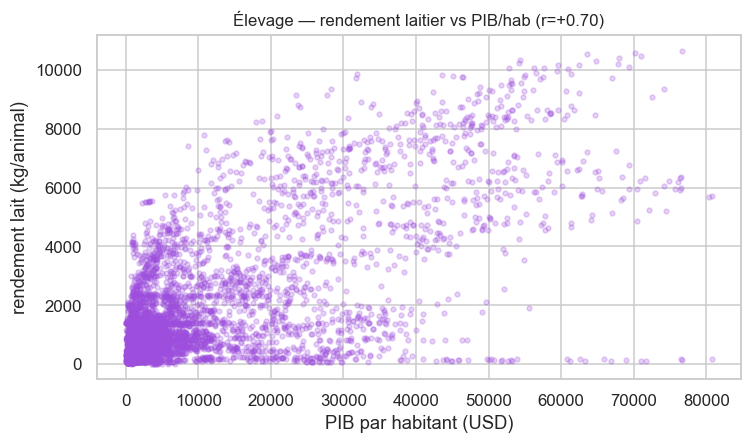

corr(rendement lait, PIB/hab) = +0.70


In [10]:
d=C1[['target_milk_yield','GDP_pc']].dropna(); d=d[d['GDP_pc']<d['GDP_pc'].quantile(.99)]
r=d['target_milk_yield'].corr(d['GDP_pc'])
fig, ax=plt.subplots(figsize=(7,4.2))
ax.scatter(d['GDP_pc'], d['target_milk_yield'], s=10, alpha=0.25, color='#9d4edd')
ax.set_title(f"Élevage — rendement laitier vs PIB/hab (r={r:+.2f})", fontsize=11)
ax.set_xlabel('PIB par habitant (USD)'); ax.set_ylabel('rendement lait (kg/animal)')
plt.tight_layout(); plt.savefig(f'{FIG}/nb2_elevage.png', bbox_inches='tight'); plt.show()
print(f"corr(rendement lait, PIB/hab) = {r:+.2f}")

**③ Hypothèse & analyse.** Corrélation **forte (+0.68)** : les pays riches ont des vaches bien plus
productives (génétique, alimentation, soins). C'est la signature de l'**intensification**.

**④ Conclusion.** Le lait (R²≈0.83) et la production d'œufs (0.85) sont les cibles élevage les mieux
prédites ; les **carcasses** (0.2-0.3) plafonnent, faute de données sur les races/l'intensification.

### 🐟 Pêche — la « révolution bleue »
**① Choix.** Série temporelle des volumes **mondiaux** de **capture sauvage** vs **aquaculture** : c'est LE
graphe pour montrer une bascule historique.

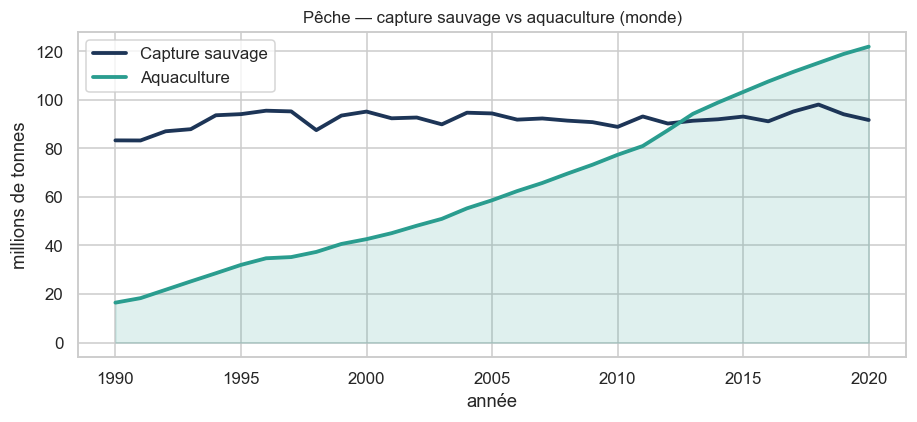

Aquaculture monde : 16 Mt (1990) -> 122 Mt (2020) | capture quasi stable 83 -> 92 Mt


In [11]:
g=C1.groupby('Annee').agg(capture=('fish_Capture_t','sum'), aqua=('aquaculture_t','sum'))/1e6
g=g[(g.index>=1990)&(g.index<=2020)]
fig, ax=plt.subplots(figsize=(8.5,4))
ax.plot(g.index, g['capture'], lw=2.5, color='#1d3557', label='Capture sauvage')
ax.plot(g.index, g['aqua'], lw=2.5, color='#2a9d8f', label='Aquaculture')
ax.fill_between(g.index, g['aqua'], color='#2a9d8f', alpha=0.15)
ax.set_title("Pêche — capture sauvage vs aquaculture (monde)", fontsize=11)
ax.set_xlabel('année'); ax.set_ylabel('millions de tonnes'); ax.legend()
plt.tight_layout(); plt.savefig(f'{FIG}/nb2_peche.png', bbox_inches='tight'); plt.show()
print(f"Aquaculture monde : {g['aqua'].iloc[0]:.0f} Mt (1990) -> {g['aqua'].iloc[-1]:.0f} Mt (2020) | "
      f"capture quasi stable {g['capture'].iloc[0]:.0f} -> {g['capture'].iloc[-1]:.0f} Mt")

**③ Hypothèse & analyse.** Hypothèse : la pêche sauvage **plafonne** (océans surexploités) et
l'aquaculture **explose**. Spectaculaire : aquaculture **×7-8** (≈16 → 122 Mt) tandis que la capture
stagne (~83 → 92 Mt). C'est la **« révolution bleue »**.

**④ Conclusion.** L'aquaculture (cible `target_aquaculture`, R²≈0.60) est désormais la dynamique majeure
du poisson — une sous-couche à part entière, pas un détail de l'agriculture.

### ⚡ Énergie — une transition très inégale
**① Choix.** Distribution de la **part d'énergie renouvelable** entre pays : un histogramme révèle si la
transition est homogène ou polarisée.

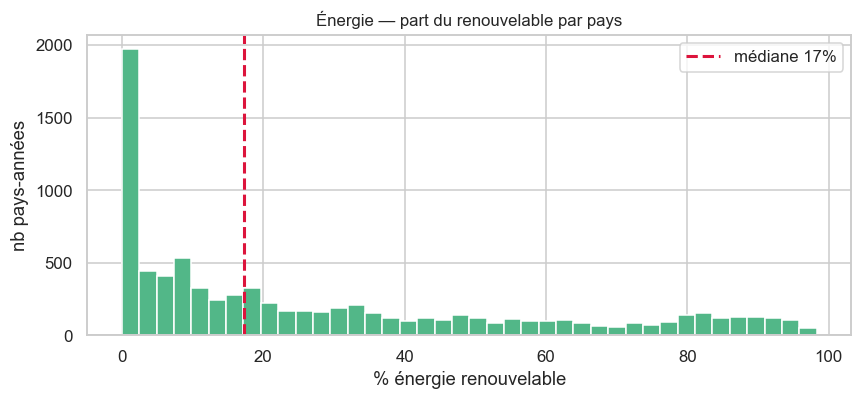

Renouvelable : médiane=17% | 25%-75% des pays entre 3% et 48%


In [12]:
r=C1['Renew_Energy_pct'].dropna()
fig, ax=plt.subplots(figsize=(8,3.8))
ax.hist(r, bins=40, color='#52b788', edgecolor='white')
ax.axvline(r.median(), color='crimson', ls='--', lw=2, label=f'médiane {r.median():.0f}%')
ax.set_title("Énergie — part du renouvelable par pays", fontsize=11)
ax.set_xlabel('% énergie renouvelable'); ax.set_ylabel('nb pays-années'); ax.legend()
plt.tight_layout(); plt.savefig(f'{FIG}/nb2_energie.png', bbox_inches='tight'); plt.show()
print(f"Renouvelable : médiane={r.median():.0f}% | 25%-75% des pays entre {r.quantile(.25):.0f}% et {r.quantile(.75):.0f}%")

**③ Hypothèse & analyse.** Hypothèse : forte **polarisation**. Confirmé — médiane ≈17% mais l'écart
interquartile va de **~3% à ~48%** : certains pays sont quasi 100% fossiles, d'autres massivement
hydro/renouvelables. Pas de profil « moyen ».

**④ Conclusion.** Les **productions** d'énergie (charbon, pétrole, gaz, hydro, éolien, solaire) sont très
bien prédites (R²≈0.72-0.90) car ancrées dans la géographie/ressources — la sous-couche énergie est l'une
des plus solides du projet.

### 🌋 Géologie — l'exposition tectonique
**① Choix.** Scatter **activité sismique × nombre de plaques tectoniques** du pays : on teste si la
sismicité est dictée par la position tectonique (et non par le hasard).

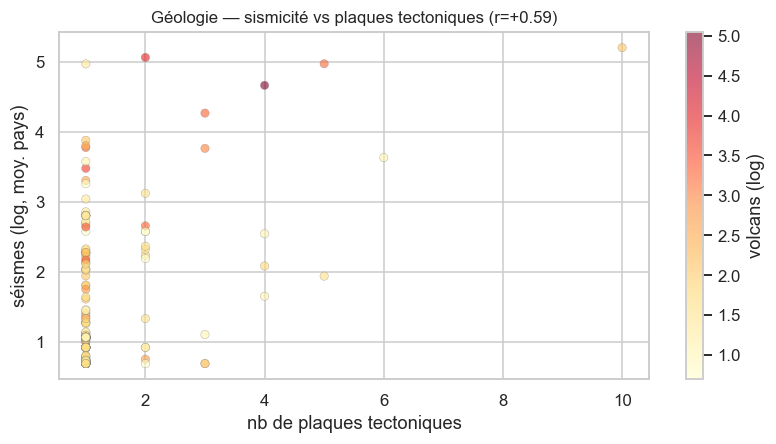

corr(séismes, plaques tectoniques) = +0.59 | les 240 pays ont une donnée volcans/faille


In [13]:
d=C1.groupby('ISO').agg(eq=('eq_count','mean'), plates=('tectonic_plates_count','mean'),
                        volc=('volcanoes_count','mean')).dropna()
r=d['eq'].corr(d['plates'])
fig, ax=plt.subplots(figsize=(7.5,4.2))
sc=ax.scatter(d['plates'], np.log1p(d['eq']), s=30, alpha=0.6, c=np.log1p(d['volc']), cmap='YlOrRd', edgecolor='grey', lw=.3)
plt.colorbar(sc, label='volcans (log)')
ax.set_title(f"Géologie — sismicité vs plaques tectoniques (r={r:+.2f})", fontsize=11)
ax.set_xlabel('nb de plaques tectoniques'); ax.set_ylabel('séismes (log, moy. pays)')
plt.tight_layout(); plt.savefig(f'{FIG}/nb2_geologie.png', bbox_inches='tight'); plt.show()
print(f"corr(séismes, plaques tectoniques) = {r:+.2f} | les 240 pays ont une donnée volcans/faille")

**③ Hypothèse & analyse.** Hypothèse : la sismicité suit la **tectonique des plaques**. Confirmé —
corrélation **+0.57** : les pays à cheval sur plusieurs plaques (et riches en volcans, points chauds)
concentrent les séismes.

**④ Conclusion.** La géologie (failles, séismes, volcans, minéraux) est une vraie sous-couche — utilisée
comme **features** par tous les modèles (et `target_seismic_activity` est modélisable). Elle ancre le projet
dans le **socle physique** du territoire.

---
## Partie B — Couche 2 « Le Sang »

### Graphique 6 — La transition démographique, vue dans les données

**① Choix & justification.** Une **série temporelle** des moyennes mondiales de **natalité** et de
**mortalité infantile** : c'est LE graphe pour visualiser un processus *dans le temps*. On teste si nos
données reproduisent un fait connu (gage de fiabilité).

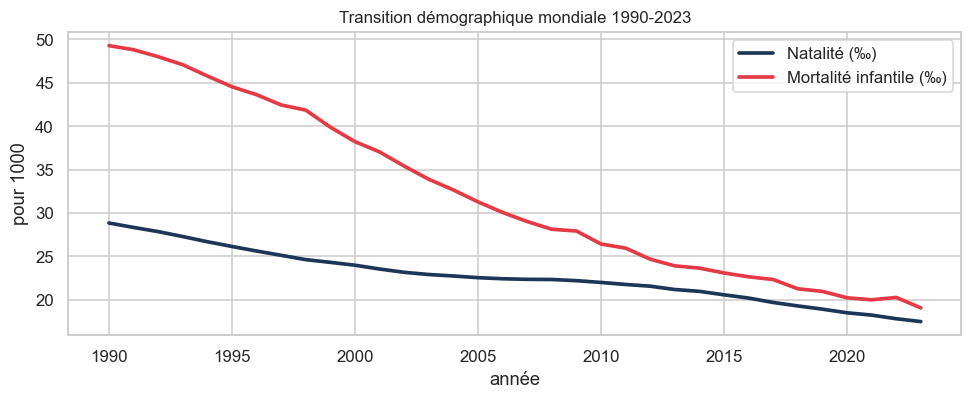

Natalité moy 1990=28.8 -> 2020=18.5 ‰ | Mort. infantile 49.3 -> 20.2 ‰


In [14]:
g=C2.groupby('Annee').agg(Natalite=('Natalite_pour1000','mean'),
                          MortInf=('MortInfantile_pour1000','mean'),
                          Fecondite=('Fecondite_enf_par_femme','mean'))
g=g[(g.index>=1990)&(g.index<=2023)]
fig, ax=plt.subplots(figsize=(9,3.8))
ax.plot(g.index, g['Natalite'], lw=2.4, color='#1d3557', label='Natalité (‰)')
ax.plot(g.index, g['MortInf'], lw=2.4, color='#e63946', label='Mortalité infantile (‰)')
ax.set_title("Transition démographique mondiale 1990-2023", fontsize=11)
ax.set_xlabel('année'); ax.set_ylabel('pour 1000'); ax.legend()
plt.tight_layout(); plt.savefig(f'{FIG}/nb2_g6_transition.png', bbox_inches='tight'); plt.show()
print(f"Natalité moy 1990={g['Natalite'].iloc[0]:.1f} -> 2020={g['Natalite'].get(2020,float('nan')):.1f} ‰ | "
      f"Mort. infantile {g['MortInf'].iloc[0]:.1f} -> {g['MortInf'].get(2020,float('nan')):.1f} ‰")

**③ Hypothèse & analyse.** Hypothèse : natalité **et** mortalité infantile **baissent** ensemble (la
transition démographique classique). Confirmé : natalité moyenne **28.8 → 18.5 ‰** et mortalité
infantile en chute parallèle sur 1990-2020.

**④ Conclusion.** Nos données **reproduisent un phénomène démographique établi** — preuve qu'elles sont
fiables et bien alignées. La forte co-évolution annonce de **fortes corrélations** entre indicateurs (G7).

### Graphique 7 — Corrélations entre indicateurs démographiques

**① Choix & justification.** **Heatmap de corrélation** des indicateurs Couche 2 : on veut savoir
lesquels sont **redondants** (et donc ne comptent qu'une fois comme « information ») et lesquels sont
indépendants. Indispensable avant de les utiliser comme cibles.

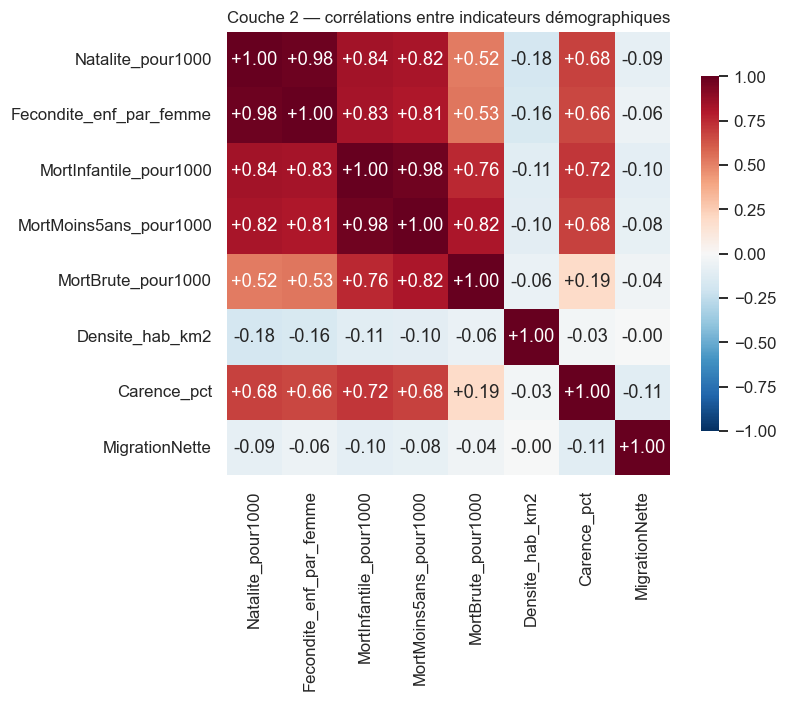

Natalité~Fécondité = +0.98 | Natalité~Mort.infantile = +0.84


In [15]:
ind=['Natalite_pour1000','Fecondite_enf_par_femme','MortInfantile_pour1000','MortMoins5ans_pour1000',
     'MortBrute_pour1000','Densite_hab_km2','Carence_pct','MigrationNette']
ind=[i for i in ind if i in C2.columns]
cm=C2[ind].corr()
fig, ax=plt.subplots(figsize=(8,6.5))
sns.heatmap(cm, annot=True, fmt='+.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink':.8}, ax=ax)
ax.set_title("Couche 2 — corrélations entre indicateurs démographiques", fontsize=11)
plt.tight_layout(); plt.savefig(f'{FIG}/nb2_g7_corr_c2.png', bbox_inches='tight'); plt.show()
print(f"Natalité~Fécondité = {cm.loc['Natalite_pour1000','Fecondite_enf_par_femme']:+.2f} | "
      f"Natalité~Mort.infantile = {cm.loc['Natalite_pour1000','MortInfantile_pour1000']:+.2f}")

**③ Hypothèse & analyse.** Hypothèse : natalité et fécondité sont **quasi interchangeables**
(r≈0.98) et le bloc natalité/fécondité/mortalité infantile forme un **régime démographique** cohérent
(pays « jeunes » à forte natalité ET forte mortalité infantile, r≈0.84). La migration nette, elle, est
**décorrélée** du reste (phénomène politique/économique).

**④ Conclusion.** Plusieurs cibles mesurent **la même réalité** → on s'attend à des R² très proches en
modélisation. La migration nette est à part — c'est cohérent avec son R² faible (notebook 3) et son
déplacement vers une « couche politique ».

### Graphique 8 — Inégalités de malnutrition selon la région

**① Choix & justification.** **Boxplot de la carence alimentaire (malnutrition) par région** : le
boxplot expose médianes *et* dispersion entre régions, parfait pour des **disparités géographiques** —
ce qui prépare le lien avec la production agricole de la Couche 1.

C:\Users\louey\AppData\Local\Temp\ipykernel_18844\336332230.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, y='Region', x='Carence_pct', order=order, palette='flare', showfliers=False, ax=ax)


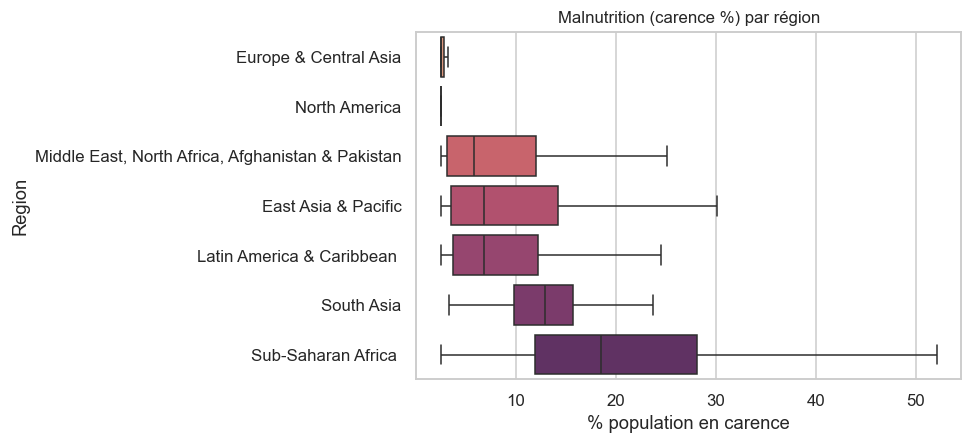

Carence médiane par région :
Region
Europe & Central Asia                                 2.5
North America                                         2.5
Middle East, North Africa, Afghanistan & Pakistan     5.8
East Asia & Pacific                                   6.8
Latin America & Caribbean                             6.8
South Asia                                           13.0
Sub-Saharan Africa                                   18.5
Name: Carence_pct, dtype: float64


In [16]:
if 'Region' in C2.columns and 'Carence_pct' in C2.columns:
    d=C2[['Region','Carence_pct']].dropna()
    order=d.groupby('Region')['Carence_pct'].median().sort_values().index
    fig, ax=plt.subplots(figsize=(9,4.2))
    sns.boxplot(data=d, y='Region', x='Carence_pct', order=order, palette='flare', showfliers=False, ax=ax)
    ax.set_title("Malnutrition (carence %) par région", fontsize=11); ax.set_xlabel('% population en carence')
    plt.tight_layout(); plt.savefig(f'{FIG}/nb2_g8_carence_region.png', bbox_inches='tight'); plt.show()
    print('Carence médiane par région :'); print(d.groupby('Region')['Carence_pct'].median().sort_values().round(1))

**③ Hypothèse & analyse.** Hypothèse : la malnutrition est **très inégale** selon les régions (Afrique
subsaharienne / Asie du Sud nettement plus touchées). Le boxplot le montre : les médianes régionales
s'étagent sur un large éventail.

**④ Conclusion.** La carence a une **structure géographique forte** — donc potentiellement explicable par
des facteurs *de territoire* (climat, sols, production). C'est précisément le pari du projet, testé au
graphique 9.

---
## Partie C — Le lien (couche supérieure) : la terre nourrit-elle les gens ?

### Graphique 9 — Rendement agricole ↔ malnutrition

**① Choix & justification.** C'est **le graphe central du projet**. Après jointure Couche 1 ⨝ Couche 2
sur `(Pays, Année)`, un **nuage de points rendement céréalier × malnutrition** avec droite de régression
teste directement l'hypothèse fondatrice. Le scatter est le seul choix qui montre la relation *et* sa force.

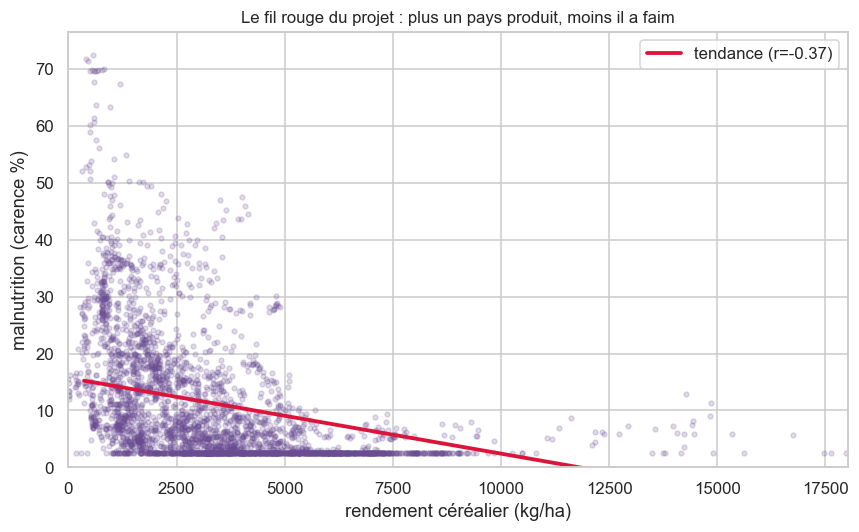

corr(rendement, malnutrition) = -0.373  sur n=3456 couples (pays, année), 154 pays


In [17]:
yld=C1.groupby(['ISO3','Annee'])[yc].mean().reset_index()
J=yld.merge(C2[['Code_Pays','Annee','Carence_pct','MortInfantile_pour1000','Natalite_pour1000','Fecondite_enf_par_femme']],
            left_on=['ISO3','Annee'], right_on=['Code_Pays','Annee'], how='inner')
d=J.dropna(subset=[yc,'Carence_pct']); d=d[d[yc]>0]
r=d[yc].corr(d['Carence_pct'])
fig, ax=plt.subplots(figsize=(8,5))
ax.scatter(d[yc], d['Carence_pct'], s=10, alpha=0.2, color='#6a4c93')
z=np.polyfit(d[yc], d['Carence_pct'],1); xs=np.linspace(d[yc].quantile(.01),d[yc].quantile(.99),50)
ax.plot(xs, np.polyval(z,xs), color='crimson', lw=2.5, label=f'tendance (r={r:+.2f})')
ax.set_title("Le fil rouge du projet : plus un pays produit, moins il a faim", fontsize=11)
ax.set_xlabel('rendement céréalier (kg/ha)'); ax.set_ylabel('malnutrition (carence %)')
ax.set_xlim(0, d[yc].quantile(.99)); ax.set_ylim(bottom=0); ax.legend()
plt.tight_layout(); plt.savefig(f'{FIG}/nb2_g9_lien.png', bbox_inches='tight'); plt.show()
print(f"corr(rendement, malnutrition) = {r:+.3f}  sur n={len(d)} couples (pays, année), {d['ISO3'].nunique()} pays")

**③ Hypothèse & analyse.** Hypothèse fondatrice : **rendement ↑ ⇒ malnutrition ↓**. La corrélation est
**négative et significative (r ≈ −0.37)** sur ~3 500 couples (pays, année). La relation n'est pas
déterministe (la richesse, les imports, la distribution jouent aussi), mais le signal de la *terre* est bien là.

**④ Conclusion.** Le projet tient sa **preuve quantitative** : l'environnement agricole d'un pays est
**réellement lié** à la santé alimentaire de sa population. C'est ce lien que le modèle inter-couches du
notebook 3 cherche à généraliser (prédire la Couche 2 à partir de la Couche 1 *seule*).

### Graphique 10 — Carte de chaleur inter-couches : la Planète × le Sang

**① Choix & justification.** Pour généraliser le G9, une **heatmap des corrélations croisées** entre
variables Couche 1 (rendement) et cibles Couche 2 (natalité, mortalités, fécondité, malnutrition). Elle
synthétise en une image *toutes* les liaisons terre→gens, au lieu d'un scatter par paire.

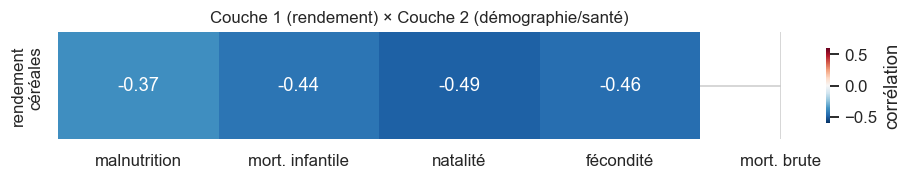

Corrélations rendement -> cibles Couche 2 :
                         yield_cereals_kgha
Carence_pct                          -0.373
MortInfantile_pour1000               -0.436
Natalite_pour1000                    -0.490
Fecondite_enf_par_femme              -0.455


In [18]:
c2t=['Carence_pct','MortInfantile_pour1000','Natalite_pour1000','Fecondite_enf_par_femme','MortBrute_pour1000']
c2t=[c for c in c2t if c in J.columns]
M=J[[yc]+c2t].corr().loc[[yc], c2t]
fig, ax=plt.subplots(figsize=(9,1.8))
sns.heatmap(M, annot=True, fmt='+.2f', cmap='RdBu_r', center=0, vmin=-0.6, vmax=0.6,
            cbar_kws={'shrink':.7,'label':'corrélation'}, ax=ax,
            yticklabels=['rendement\ncéréales'], xticklabels=['malnutrition','mort. infantile','natalité','fécondité','mort. brute'])
ax.set_title("Couche 1 (rendement) × Couche 2 (démographie/santé)", fontsize=11)
plt.tight_layout(); plt.savefig(f'{FIG}/nb2_g10_intercouches.png', bbox_inches='tight'); plt.show()
print('Corrélations rendement -> cibles Couche 2 :')
print(M.T.round(3))

**③ Hypothèse & analyse.** Hypothèse : un **meilleur rendement** est associé à une **démographie plus
« mûre »** — moins de malnutrition, moins de mortalité infantile, **natalité et fécondité plus basses**.
Les corrélations confirment toutes le même sens : rendement ↔ natalité **−0.49**, ↔ fécondité **−0.46**,
↔ mortalité infantile **−0.44**, ↔ malnutrition **−0.37**.

**④ Conclusion.** Le lien terre→gens n'est pas une coïncidence sur une variable : il est **cohérent sur
tout le bloc démographique**. Cela fonde l'idée centrale — *prédire la Couche 2 à partir de la Couche 1* —
mise à l'épreuve par les modèles du notebook 3.

---
## Synthèse de l'exploration
- **Couche 1 — toutes les sous-couches** :
  - *Agriculture* : rendement asymétrique (→ log), piloté par les **intrants** plus que le climat ; **clusters** agro-climatiques pertinents.
  - *Atmosphère* : CO₂ adossé à l'**énergie fossile** (r≈0.65-0.69).
  - *Hydrologie* : accès à l'eau = **infrastructure** plus que ressource physique (lien faible avec le stress).
  - *Sol/écologie* : plus un pays est boisé, plus il perd de couvert en absolu (r≈0.37).
  - *Élevage* : rendement laitier ∝ **richesse** (intensification, r≈0.68).
  - *Pêche* : **révolution bleue** — aquaculture ×7-8, dépasse la capture sauvage vers 2013.
  - *Énergie* : transition **très polarisée** (renouvelable 3%→48% selon les pays).
  - *Géologie* : sismicité dictée par la **tectonique** (r≈0.57).
- **Couche 2** : les données **reproduisent la transition démographique** ; natalité/fécondité quasi redondantes ; malnutrition à **forte structure régionale**.
- **Le lien** : corrélations **négatives et cohérentes** entre rendement et tout le bloc démographie/santé (−0.37 à −0.49) → l'hypothèse « la terre nourrit les gens » est **validée en exploration**, à confirmer en modélisation.